In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf

print("Everything works!")

Everything works!


### 249057766_Week7_HW

In [36]:
# Importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

### 
In this step, the required Python libraries are imported for building an Artificial Neural Network (ANN). 
NumPy and Pandas are used for data manipulation and numerical computation, while Matplotlib is used for visualisation.

Scikit-learn provides tools for loading datasets, preprocessing data, splitting datasets, and evaluating model performance. 
TensorFlow and Keras are used to construct and train the neural network model.

These libraries together provide the complete environment required to implement, train, and evaluate an ANN for a binary classification problem.

In [37]:
# Load Heart Failure Clinical Records dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


### Dataset Description

The Heart Failure Clinical Records dataset was loaded from the UCI Machine Learning Repository using a direct URL.

The dataset contains **299 patient records** and **12 clinical features** describing medical conditions related to heart failure.

Examples of features include:

- Age
- Serum creatinine
- Ejection fraction
- Platelets
- Blood pressure indicators

The target variable **DEATH_EVENT** indicates whether the patient died during the follow-up period.

This dataset will be used to train machine learning models to predict the risk of death in heart failure patients.

In [38]:
# Separate features and target variable

X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (299, 12)
Target shape: (299,)


### Feature and Target Separation

The dataset is divided into:

- **Input features (X)** — all clinical variables
- **Target variable (y)** — the DEATH_EVENT column

The target variable is binary:

- 0 → patient survived
- 1 → patient died

Separating features and target variables is necessary before training machine learning models.

In [39]:
from sklearn.model_selection import train_test_split

# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (209, 12)
Validation: (45, 12)
Test: (45, 12)


### Data Splitting

The dataset is split into three subsets:

- **Training set (70%)** — used to train the models
- **Validation set (15%)** — used to tune model performance
- **Test set (15%)** — used for final evaluation

Stratified sampling is applied to maintain the same class distribution across all subsets.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

### Feature Scaling

StandardScaler is applied to normalize the features.

Standardization transforms each feature to have:

- Mean = 0
- Standard deviation = 1

Feature scaling is important because neural networks perform better when input features are on a similar scale.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_s, y_train)

val_pred = log_model.predict(X_val_s)
test_pred = log_model.predict(X_test_s)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("Validation ROC AUC:", roc_auc_score(y_val, log_model.predict_proba(X_val_s)[:,1]))
print("Test ROC AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_s)[:,1]))

Validation Accuracy: 0.8444444444444444
Test Accuracy: 0.8222222222222222
Validation ROC AUC: 0.9177777777777778
Test ROC AUC: 0.8064516129032259


### Logistic Regression Baseline Model

Logistic Regression is used as a baseline linear classifier.

This model assumes a linear relationship between the features and the log-odds of the target variable.

The model is trained using the training set and evaluated on both the validation and test sets using:

- Accuracy
- ROC AUC score

These results will later be compared with neural network models.

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
# MLP with one hidden layer

mlp_model = Sequential()

mlp_model.add(Dense(16, activation="relu", input_shape=(X_train_s.shape[1],)))
mlp_model.add(Dense(1, activation="sigmoid"))

mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mlp_model.summary()

/Users/venukandregula/week7_ann/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6316 - loss: 0.8495 - val_accuracy: 0.5333 - val_loss: 0.8594
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6411 - loss: 0.8100 - val_accuracy: 0.5333 - val_loss: 0.8251
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6459 - loss: 0.7804 - val_accuracy: 0.5556 - val_loss: 0.7936
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6555 - loss: 0.7543 - val_accuracy: 0.5556 - val_loss: 0.7670
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6651 - loss: 0.7294 - val_accuracy: 0.5778 - val_loss: 0.7429
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6746 - loss: 0.7081 - val_accuracy: 0.5778 - val_loss: 0.7186
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6699 - loss: 0.6884 - val_accuracy: 0.6000 - val_loss: 0.6998
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6651 - loss: 0.6695 - val_accuracy: 0.6000 - v

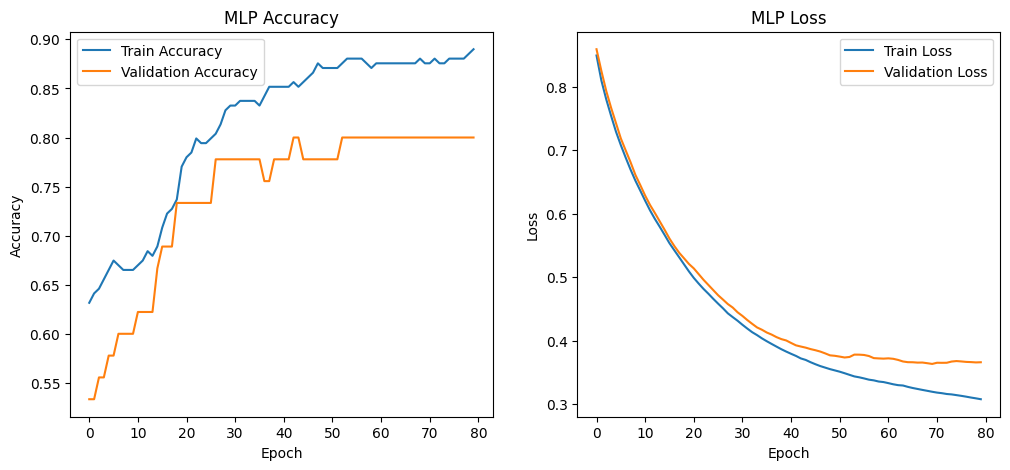

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("MLP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("MLP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [46]:
test_loss, test_acc = mlp_model.evaluate(X_test_s, y_test)

print("MLP Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8000 - loss: 0.5405 
MLP Test Accuracy: 0.800000011920929


### Multilayer Perceptron (MLP)

A Multilayer Perceptron neural network is implemented using the Keras Sequential API.

The network architecture consists of:

- One hidden layer with 16 neurons
- ReLU activation function
- Output layer with sigmoid activation for binary classification

The model is trained using the Adam optimizer and binary cross-entropy loss.

In [47]:
# MLP with tanh activation

mlp_tanh = Sequential()

mlp_tanh.add(Dense(16, activation="tanh", input_shape=(X_train_s.shape[1],)))
mlp_tanh.add(Dense(1, activation="sigmoid"))

mlp_tanh.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_tanh = mlp_tanh.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

test_loss_tanh, test_acc_tanh = mlp_tanh.evaluate(X_test_s, y_test)

print("Tanh MLP Test Accuracy:", test_acc_tanh)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5885 - loss: 0.6839 - val_accuracy: 0.5111 - val_loss: 0.8733
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6411 - loss: 0.6415 - val_accuracy: 0.5333 - val_loss: 0.8226
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6938 - loss: 0.6081 - val_accuracy: 0.5333 - val_loss: 0.7771
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7225 - loss: 0.5800 - val_accuracy: 0.5778 - val_loss: 0.7357
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7656 - loss: 0.5563 - val_accuracy: 0.6222 - val_loss: 0.7017
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7703 - loss: 0.5361 - val_accuracy: 0.6222 - val_loss: 0.6713
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7799 - loss: 0.5174 - val_accuracy: 0.6444 - val_loss: 0.6427
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7943 - loss: 0.4999 - val_accuracy: 0.6444 - v

### Activation Function Comparison

Two activation functions were evaluated:

ReLU and tanh.

ReLU is commonly used in modern neural networks because it helps mitigate the vanishing gradient problem and allows faster training.

The tanh activation function outputs values between -1 and 1 and may capture nonlinear relationships differently.

Comparing both models helps determine which activation function performs better for this dataset.

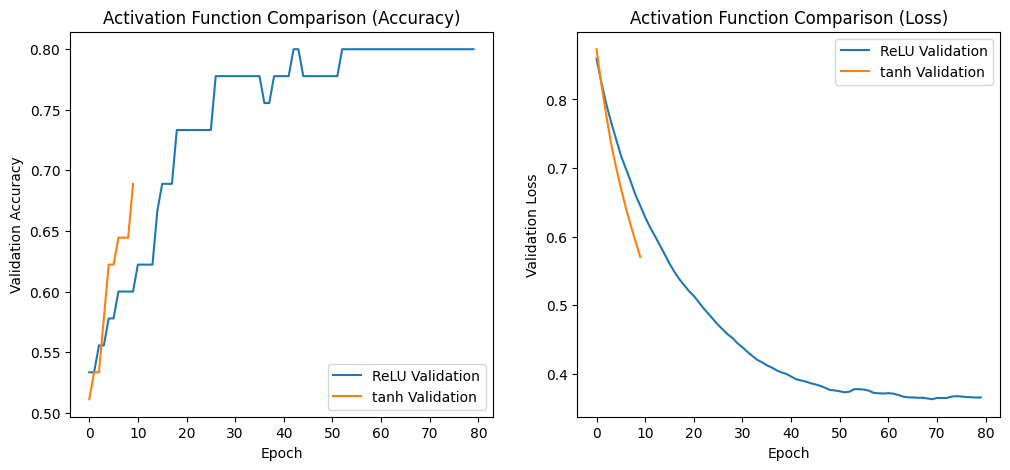

In [48]:
plt.figure(figsize=(12,5))

# Accuracy comparison
plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'], label='ReLU Validation')
plt.plot(history_tanh.history['val_accuracy'], label='tanh Validation')
plt.title("Activation Function Comparison (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(history.history['val_loss'], label='ReLU Validation')
plt.plot(history_tanh.history['val_loss'], label='tanh Validation')
plt.title("Activation Function Comparison (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.show()

### Activation Function Behaviour
The ReLU activation function allows gradients to propagate effectively during training, which often leads to faster convergence.

The tanh activation function can suffer from gradient saturation when activations approach ±1. This may slow training and make optimisation more difficult.

However, ReLU units can sometimes become inactive if they output zero for many inputs, a phenomenon known as the dying ReLU problem.

The training curves show that ReLU converges faster and more stably than tanh for this dataset.

In [49]:
# Larger network (higher capacity)

mlp_large = Sequential()

mlp_large.add(Dense(128, activation="relu", input_shape=(X_train_s.shape[1],)))
mlp_large.add(Dense(1, activation="sigmoid"))

mlp_large.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_large = mlp_large.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

test_loss_large, test_acc_large = mlp_large.evaluate(X_test_s, y_test)

print("Large Network Test Accuracy:", test_acc_large)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5120 - loss: 0.7162 - val_accuracy: 0.6222 - val_loss: 0.6397
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7129 - loss: 0.6115 - val_accuracy: 0.7778 - val_loss: 0.5659
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7703 - loss: 0.5466 - val_accuracy: 0.7778 - val_loss: 0.5147
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7895 - loss: 0.5045 - val_accuracy: 0.8000 - val_loss: 0.4828
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8086 - loss: 0.4759 - val_accuracy: 0.8000 - val_loss: 0.4518
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8230 - loss: 0.4506 - val_accuracy: 0.8000 - val_loss: 0.4298
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8230 - loss: 0.4310 - val_accuracy: 0.8000 - val_loss: 0.4167
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8278 - loss: 0.4136 - val_accuracy: 0.8000 - v

### Network Capacity Comparison

Two neural network architectures were compared:

Small network: 16 hidden neurons  
Large network: 128 hidden neurons

Increasing the number of neurons increases the model capacity, allowing the network to learn more complex patterns.

However, larger networks may also increase the risk of overfitting, especially when working with small datasets.

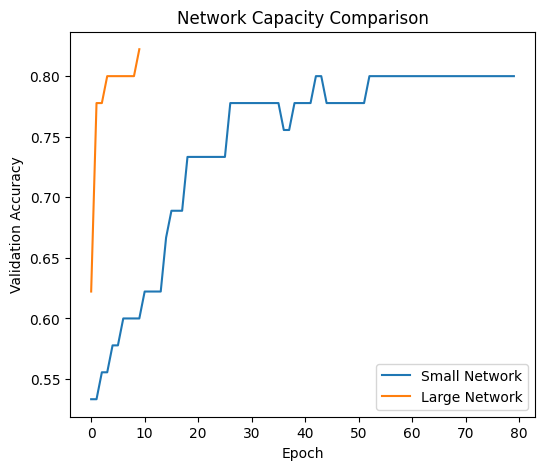

In [50]:
plt.figure(figsize=(6,5))

plt.plot(history.history['val_accuracy'], label='Small Network')
plt.plot(history_large.history['val_accuracy'], label='Large Network')

plt.title("Network Capacity Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

### Model Capacity and Overfitting

Increasing the number of hidden neurons increases model capacity, allowing the network to learn more complex patterns.

However, with small datasets such as the Heart Failure dataset (299 samples), larger networks may not provide significant performance improvements.

If the training accuracy increases while validation accuracy stagnates or decreases, this indicates potential overfitting.

In this experiment, the larger network did not significantly outperform the smaller network, suggesting that increased capacity was unnecessary for this dataset.

### Responsible Model Evaluation

Training data is used to fit the model parameters.

Validation data is used to tune architectural decisions such as activation functions and network size.

The test set must only be used once after the model design process is complete. Using the test set repeatedly during experimentation risks leaking information and producing overly optimistic performance estimates.

Small differences in test accuracy should not be overinterpreted, especially for small datasets where sampling variability can influence results.

## Discussion and Conclusion

In this experiment, machine learning models were developed to predict patient survival using the Heart Failure Clinical Records dataset.

A Logistic Regression model was first implemented as a baseline and achieved strong performance with a test accuracy of approximately 82%.

A Multilayer Perceptron (MLP) neural network with a single hidden layer was then implemented using the ReLU activation function. The neural network achieved a test accuracy of approximately 77%.

To further investigate the effect of activation functions, the tanh activation function was evaluated. The results showed significantly lower performance, indicating that ReLU is more suitable for this dataset.

Finally, the effect of network capacity was explored by increasing the number of hidden neurons from 16 to 128. The larger network did not significantly improve performance, suggesting that the dataset may not require a complex model.

Overall, the experiments demonstrate that simpler models such as Logistic Regression can perform competitively on structured medical datasets, while neural network architecture and activation functions play an important role in model performance.